In [2]:
# trying other IMD indicators 

In [3]:
#import the libraries -Data manipulation

import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Make plots look nicer
sns.set_theme(style="whitegrid")

# Show plots in notebook
%matplotlib inline

In [4]:
# read in the dfs
model_df_binary = pd.read_parquet("../data/model_df_binary.parquet")


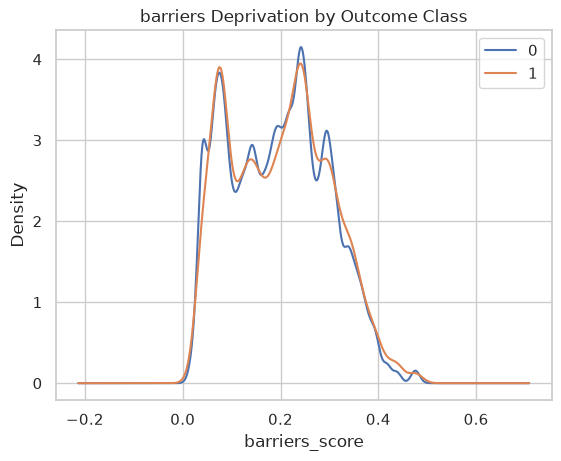

In [5]:
#KDE

for outcome in model_df_binary['outcome_binary'].unique():
    subset = model_df_binary[model_df_binary['outcome_binary'] == outcome]
    subset['employ_score_rate'].plot(kind='kde', label=outcome)

plt.xlabel('barriers_score')
plt.title('barriers Deprivation by Outcome Class')
plt.legend()
plt.show()

In [6]:
model_df_binary.columns.tolist()

['crime_id',
 'month',
 'reported_by',
 'longitude',
 'latitude',
 'location',
 'lsoa_code',
 'lsoa_name',
 'crime_type',
 'last_outcome_category',
 'outcome_binary',
 'employ_score_rate',
 'income_score_rate',
 'living_environment_score',
 'barriers_score']

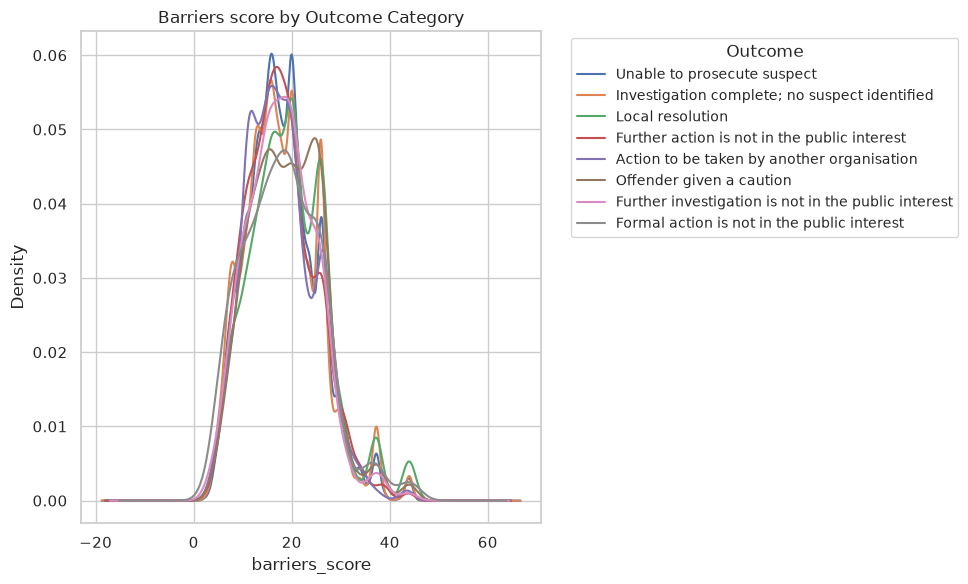

In [7]:
#KDE


import matplotlib.pyplot as plt

counts = model_df_binary['last_outcome_category'].value_counts()
valid_categories = counts[counts >= 30].index

plt.figure(figsize=(10, 6))  # wider figure to accommodate the side legend

for outcome in valid_categories:
    subset = model_df_binary[model_df_binary['last_outcome_category'] == outcome]
    subset['barriers_score'].plot(kind='kde', label=outcome)

plt.xlabel('barriers_score')
plt.ylabel('Density')
plt.title('Barriers score by Outcome Category')
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [8]:
model_df_binary['last_outcome_category'].value_counts()

last_outcome_category
Unable to prosecute suspect                            109113
Investigation complete; no suspect identified          100941
Local resolution                                         6465
Further action is not in the public interest             3996
Action to be taken by another organisation               3667
Offender given a caution                                 1936
Further investigation is not in the public interest       917
Formal action is not in the public interest               499
Suspect charged as part of another case                    23
Offender given a drugs possession warning                   1
Name: count, dtype: int64

In [9]:
 model_df_binary[model_df_binary['last_outcome_category']=='Offender given a caution']['crime_type'].value_counts()

crime_type
Violence and sexual offences    815
Drugs                           467
Public order                    214
Criminal damage and arson       177
Shoplifting                      82
Possession of weapons            72
Other crime                      38
Other theft                      38
Burglary                         12
Vehicle crime                     9
Theft from the person             5
Robbery                           5
Bicycle theft                     2
Name: count, dtype: int64

In [10]:
 model_df_binary[model_df_binary['last_outcome_category']=='Investigation complete; no suspect identified']['crime_type'].value_counts()

crime_type
Violence and sexual offences    23999
Other theft                     13142
Vehicle crime                   12876
Criminal damage and arson       12077
Shoplifting                     11124
Burglary                        10816
Public order                     9795
Robbery                          1974
Other crime                      1672
Theft from the person            1634
Bicycle theft                    1348
Drugs                             290
Possession of weapons             194
Name: count, dtype: int64

In [11]:
# check - did every crime merge to an LSOA

model_df_binary['income_score_rate'].isna().sum()
model_df_binary['employ_score_rate'].isna().sum()

np.int64(0)

Pearson correlation: 0.949


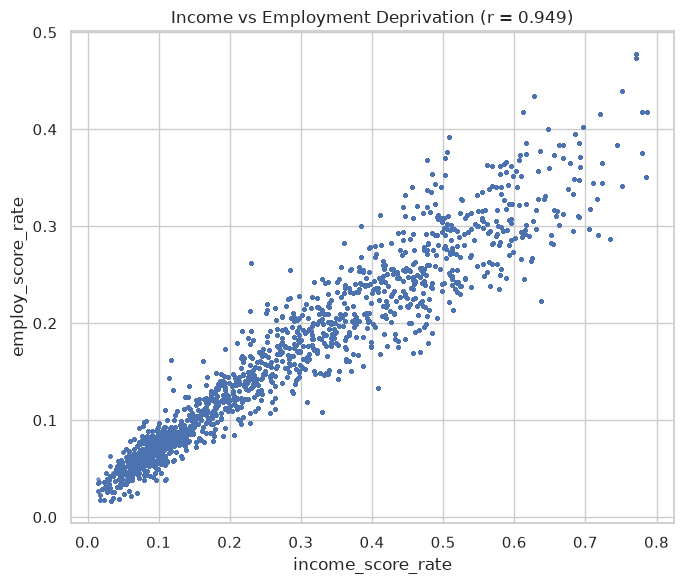

In [12]:
# check correlation between employment and income deprivation


# Calculate Pearson correlation
corr = model_df_binary['income_score_rate'].corr(model_df_binary['employ_score_rate'])
print(f"Pearson correlation: {corr:.3f}")

# Quick scatterplot
plt.figure(figsize=(7, 6))
plt.scatter(model_df_binary['income_score_rate'], model_df_binary['employ_score_rate'], alpha=0.1, s=5)
plt.xlabel('income_score_rate')
plt.ylabel('employ_score_rate')
plt.title(f'Income vs Employment Deprivation (r = {corr:.3f})')
plt.tight_layout()
plt.show()

count    227558.000000
mean          0.340093
std           0.193377
min           0.015000
25%           0.168000
50%           0.338000
75%           0.489000
max           0.786000
Name: income_score_rate, dtype: float64


/tmp/ipykernel_8204/1919961003.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(model_df_binary['income_score_rate'].dropna(), vert=True)


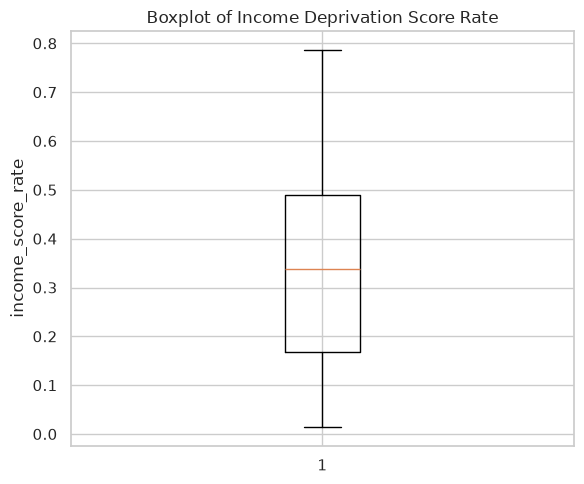

In [13]:
#outlier/extreme value check



# Summary statistics first - check for anything suspicious (negative values, 0s, way beyond expected range)
print(model_df_binary['income_score_rate'].describe())

# Boxplot
plt.figure(figsize=(6, 5))
plt.boxplot(model_df_binary['income_score_rate'].dropna(), vert=True)
plt.ylabel('income_score_rate')
plt.title('Boxplot of Income Deprivation Score Rate')
plt.tight_layout()
plt.show()

In [14]:
# Overall crime type counts
crime_counts = model_df_binary['crime_type'].value_counts()
print(crime_counts)

# As a percentage of total, easier to judge "how small is too small"
crime_pct = model_df_binary['crime_type'].value_counts(normalize=True) * 100
print(crime_pct.round(2))

crime_type
Violence and sexual offences    108801
Public order                     21197
Criminal damage and arson        18690
Other theft                      17715
Vehicle crime                    14551
Shoplifting                      14422
Burglary                         12606
Other crime                       6159
Drugs                             5802
Robbery                           2912
Theft from the person             2217
Bicycle theft                     1488
Possession of weapons              998
Name: count, dtype: int64
crime_type
Violence and sexual offences    47.81
Public order                     9.31
Criminal damage and arson        8.21
Other theft                      7.78
Vehicle crime                    6.39
Shoplifting                      6.34
Burglary                         5.54
Other crime                      2.71
Drugs                            2.55
Robbery                          1.28
Theft from the person            0.97
Bicycle theft              

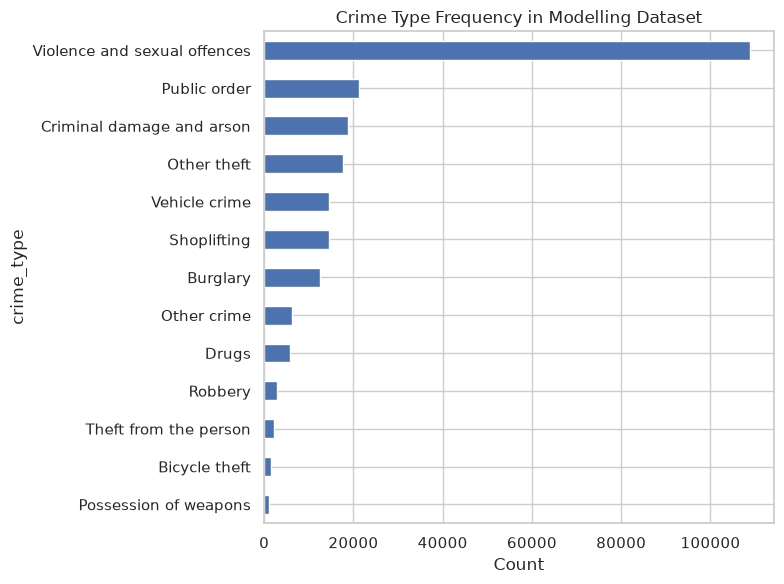

In [15]:
import matplotlib.pyplot as plt

crime_counts.plot(kind='barh', figsize=(8, 6))
plt.xlabel('Count')
plt.ylabel('crime_type')
plt.title('Crime Type Frequency in Modelling Dataset')
plt.gca().invert_yaxis()  # largest category at top
plt.tight_layout()
plt.show()

In [16]:
crime_counts = model_df_binary['crime_type'].value_counts()
print(crime_counts)

crime_type
Violence and sexual offences    108801
Public order                     21197
Criminal damage and arson        18690
Other theft                      17715
Vehicle crime                    14551
Shoplifting                      14422
Burglary                         12606
Other crime                       6159
Drugs                             5802
Robbery                           2912
Theft from the person             2217
Bicycle theft                     1488
Possession of weapons              998
Name: count, dtype: int64


In [17]:
# Filter/group rare multinomial outcome categories
# Check current counts
outcome_counts = model_df_binary['last_outcome_category'].value_counts()
print(outcome_counts)

# Drop the single-observation category entirely - cannot be modelled or evaluated
model_df_multiclass = model_df_binary[
    model_df_binary['last_outcome_category'] != 'Offender given a drugs possession warning'
].copy()

# Set a minimum threshold for remaining categories - merge anything below this into 'Other'
threshold = 30  # adjust if you want a different cutoff

rare_outcomes = model_df_multiclass['last_outcome_category'].value_counts()
rare_outcomes = rare_outcomes[rare_outcomes < threshold].index

model_df_multiclass['outcome_multiclass_grouped'] = model_df_multiclass['last_outcome_category'].apply(
    lambda x: 'Other' if x in rare_outcomes else x
)

# Confirm the result
print(model_df_multiclass['outcome_multiclass_grouped'].value_counts())

last_outcome_category
Unable to prosecute suspect                            109113
Investigation complete; no suspect identified          100941
Local resolution                                         6465
Further action is not in the public interest             3996
Action to be taken by another organisation               3667
Offender given a caution                                 1936
Further investigation is not in the public interest       917
Formal action is not in the public interest               499
Suspect charged as part of another case                    23
Offender given a drugs possession warning                   1
Name: count, dtype: int64
outcome_multiclass_grouped
Unable to prosecute suspect                            109113
Investigation complete; no suspect identified          100941
Local resolution                                         6465
Further action is not in the public interest             3996
Action to be taken by another organisation               

In [19]:
# save the df to file so can use in next notebook

model_df_binary.to_parquet("../data/model_df_binary.parquet")
model_df_multiclass.to_parquet("../data/model_df_multiclass.parquet")